# Phase 4 — EDA and data cleaning

**Look at the data before writing a feature.** Three things are decided here and nowhere
else:

1. **The lag set.** Chosen from the partial autocorrelation, not from "1/2/3/6/12/24/48 looks
   reasonable".
2. **Whether the spatial features are justified.** If neighbouring stations do not correlate,
   neighbour columns are noise with a story attached.
3. **What, if anything, gets cleaned.** Three checks that nothing in this repo runs today.

Re-runnable top to bottom — *Run All* is the reproducibility story. It reads only the
gitignored `data/pm25_history.csv` and writes `docs/eda.md`, so it costs **zero Neon wakes**.

**No row is dropped silently.** A rule found here is adopted only as a named constant in
`scripts/features.py` carrying its count, or it is not applied. Build plan §0.5.

In [1]:
import os, sys, math, textwrap
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "scripts"))
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
import features
from baselines import CACHE, IST, SEVERE_ABOVE
import aqi

# Paul Tol's "bright" set: distinguishable under the three common colour-vision
# deficiencies, which matplotlib's default cycle is not. Named, so a chart picks
# a colour by meaning rather than by position in a list.
PAL = {"blue": "#4477aa", "cyan": "#66ccee", "green": "#228833",
       "yellow": "#ccbb44", "red": "#ee6677", "purple": "#aa3377",
       "grey": "#bbbbbb", "ink": "#333333", "muted": "#777777"}

plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 120, "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": .25, "grid.color": "#cccccc",
    "axes.axisbelow": True,                       # grid behind the data, never over it
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999",
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": PAL["ink"], "axes.labelsize": 9, "axes.labelcolor": PAL["muted"],
    "xtick.labelsize": 8, "ytick.labelsize": 8, "xtick.color": PAL["muted"],
    "ytick.color": PAL["muted"], "font.size": 9, "legend.frameon": False,
})
MONTHS = ["", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def titles(ax, finding, detail=None):
    """Title says the FINDING; the grey subtitle says what is plotted.

    A title reading "PM2.5 by hour" makes the reader do the work twice — once to
    read the chart and once to decide what it meant.
    """
    ax.set_title(finding, pad=16 if detail else 8)
    if detail:
        ax.text(0, 1.015, detail, transform=ax.transAxes, fontsize=8.5,
                color=PAL["muted"], va="bottom")

def bandline(ax, y=SEVERE_ABOVE, label=None, colour=None):
    """One dashed reference line, labelled in place instead of in a legend."""
    ax.axhline(y, ls="--", lw=.9, color=colour or PAL["ink"])
    ax.text(1.0, y, f" {label or f'severe {y:.0f}'}", transform=ax.get_yaxis_transform(),
            va="center", fontsize=8, color=colour or PAL["muted"])

raw = pd.read_csv(CACHE, parse_dates=["observation_ts"])
raw["hour"] = features.to_hour(raw["observation_ts"])
raw["ist"] = raw["observation_ts"].dt.tz_convert(IST)

# load_wide reindexes onto a COMPLETE hourly grid (NaN at the gaps) and masks
# exact zeros -- see section 7a for the evidence behind that rule. `raw` below
# is untouched, so 7a can still count what was masked.
wide = features.load_wide()
REPORT = []                          # markdown lines -> docs/eda.md

def note(text):
    REPORT.append(textwrap.dedent(text).strip())
    print(textwrap.dedent(text).strip())

# DataFrame -> markdown. pandas' own .to_markdown needs `tabulate`, and a new
# dependency for four lines of string join is not worth it.
def mdtable(df):
    head = "| " + " | ".join(map(str, df.columns)) + " |"
    rule = "|" + "---|" * len(df.columns)
    body = ["| " + " | ".join(map(str, r)) + " |" for r in df.itertuples(index=False)]
    return "\n".join([head, rule] + body)

note(f'''
    Rows: {len(raw):,}
    Stations: {raw.station_id.nunique()}
    Span: {raw.ist.min():%Y-%m-%d} to {raw.ist.max():%Y-%m-%d} IST
    Hourly grid: {len(wide):,} hours x {len(wide.columns)} stations
    Slots present: {wide.notna().mean().mean():.1%}
''')

Rows: 194,059
Stations: 30
Span: 2025-02-19 to 2026-08-22 IST
Hourly grid: 13,190 hours x 30 stations
Slots present: 47.9%


## 1. Coverage

Two questions: how much history does each station have, and **when**. The second matters more
— a station with 7,000 rows all in summer cannot help a winter fold.

In [2]:
per = raw.groupby("station_id").agg(
    rows=("value", "size"), first=("ist", "min"), last=("ist", "max"))
per["months"] = ((per["last"] - per["first"]).dt.days / 30.44).round(1)
per["pct_of_span"] = (per["rows"] / ((per["last"] - per["first"])
                      .dt.total_seconds() / 3600)).round(3)
display(per.sort_values("rows", ascending=False))

note(f'''
    ## Coverage

    - Stations with >= 12 months of span: **{(per.months >= 12).sum()}** of {len(per)}
    - Stations with >= 6 months: **{(per.months >= 6).sum()}**
    - Thinnest station: **{per.rows.min():,}** rows; fattest **{per.rows.max():,}**
    - Median fill within a station's own span: **{per.pct_of_span.median():.1%}**
''')

,rows,first,last,months,pct_of_span
station_id,,,,,
1,11329,2025-02-19 01:00:00+05:30,2026-08-22 13:00:00+05:30,18.0,0.859
14,7857,2025-02-19 01:00:00+05:30,2026-08-22 13:00:00+05:30,18.0,0.596
9,7845,2025-02-19 01:00:00+05:30,2026-08-22 13:00:00+05:30,18.0,0.595
23,7720,2025-02-19 01:00:00+05:30,2026-08-22 13:00:00+05:30,18.0,0.585
18,7511,2025-02-19 01:00:00+05:30,2026-08-22 13:00:00+05:30,18.0,0.570
26,7156,2025-09-27 12:00:00+05:30,2026-08-22 13:00:00+05:30,10.8,0.906
20,6976,2025-10-03 13:00:00+05:30,2026-08-22 13:00:00+05:30,10.6,0.900
25,6953,2025-09-29 10:00:00+05:30,2026-08-22 13:00:00+05:30,10.7,0.886
15,6791,2025-10-01 12:00:00+05:30,2026-08-22 13:00:00+05:30,10.7,0.871


## Coverage

- Stations with >= 12 months of span: **12** of 30
- Stations with >= 6 months: **29**
- Thinnest station: **232** rows; fattest **11,329**
- Median fill within a station's own span: **81.3%**


C:\Users\sumee\AppData\Local\Temp\ipykernel_5016\2252098467.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = raw.groupby(raw.ist.dt.to_period("M")).agg(
C:\Users\sumee\AppData\Local\Temp\ipykernel_5016\2252098467.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


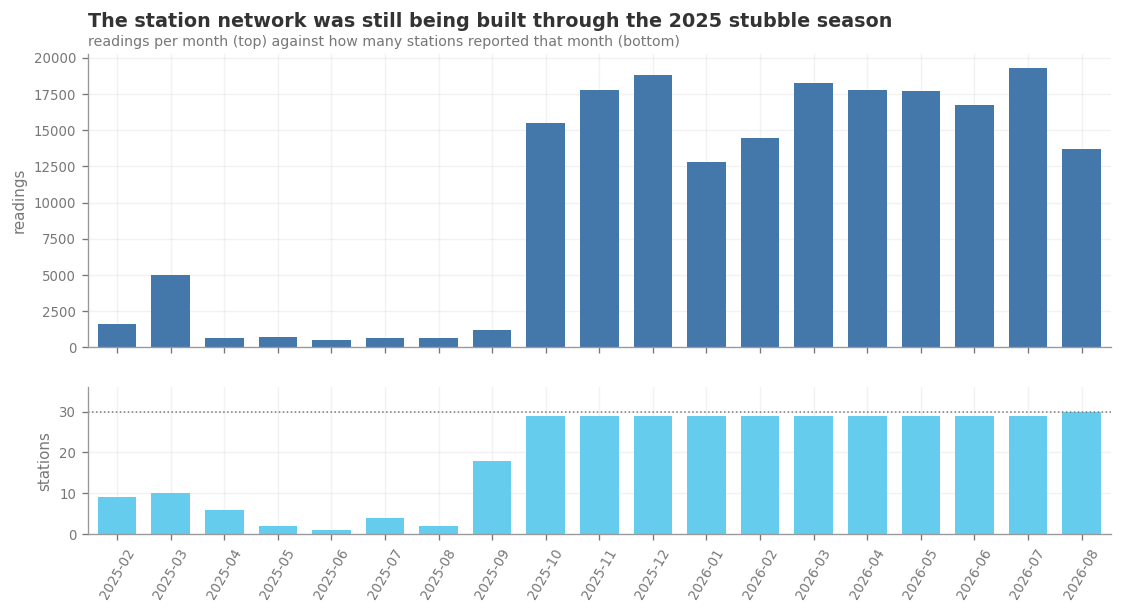

- Winter months (Oct-Feb) carry **81,074 rows, 42%** of the data.
  That is what makes fold 1 of the benchmark worth having: the severe events live there.
- Before **2025-10** only ~5 stations reported, so fold 1's training block is thin and
  station-skewed. Stated in the README rather than fixed by moving the boundary.


In [3]:
# Two measures on two scales get two panels. A twin y-axis lets the reader
# infer a crossing that is an artefact of where the two scales were placed.
monthly = raw.groupby(raw.ist.dt.to_period("M")).agg(
    rows=("value", "size"), stations=("station_id", "nunique"))
x = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1], "hspace": .18})
axes[0].bar(x, monthly["rows"], color=PAL["blue"], width=.72)
axes[0].set_ylabel("readings")
titles(axes[0], "The station network was still being built through the 2025 stubble season",
       "readings per month (top) against how many stations reported that month (bottom)")
axes[1].bar(x, monthly["stations"], color=PAL["cyan"], width=.72)
axes[1].set_ylabel("stations")
axes[1].set_ylim(0, monthly["stations"].max() * 1.2)
axes[1].axhline(monthly["stations"].max(), ls=":", lw=.9, color=PAL["muted"])
for ax in axes:
    ax.margins(x=.01)
plt.xticks(rotation=60)
plt.tight_layout(); plt.show()

winter = monthly[monthly.index.month.isin([10, 11, 12, 1, 2])]["rows"].sum()
note(f'''
    - Winter months (Oct-Feb) carry **{winter:,} rows, {winter/len(raw):.0%}** of the data.
      That is what makes fold 1 of the benchmark worth having: the severe events live there.
    - Before **2025-10** only ~5 stations reported, so fold 1's training block is thin and
      station-skewed. Stated in the README rather than fixed by moving the boundary.
''')

C:\Users\sumee\AppData\Local\Temp\ipykernel_5016\3211606161.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  grid = (raw.assign(month=raw.ist.dt.to_period("M").astype(str))
C:\Users\sumee\AppData\Local\Temp\ipykernel_5016\3211606161.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hours_in_month = (raw.assign(month=raw.ist.dt.to_period("M"))


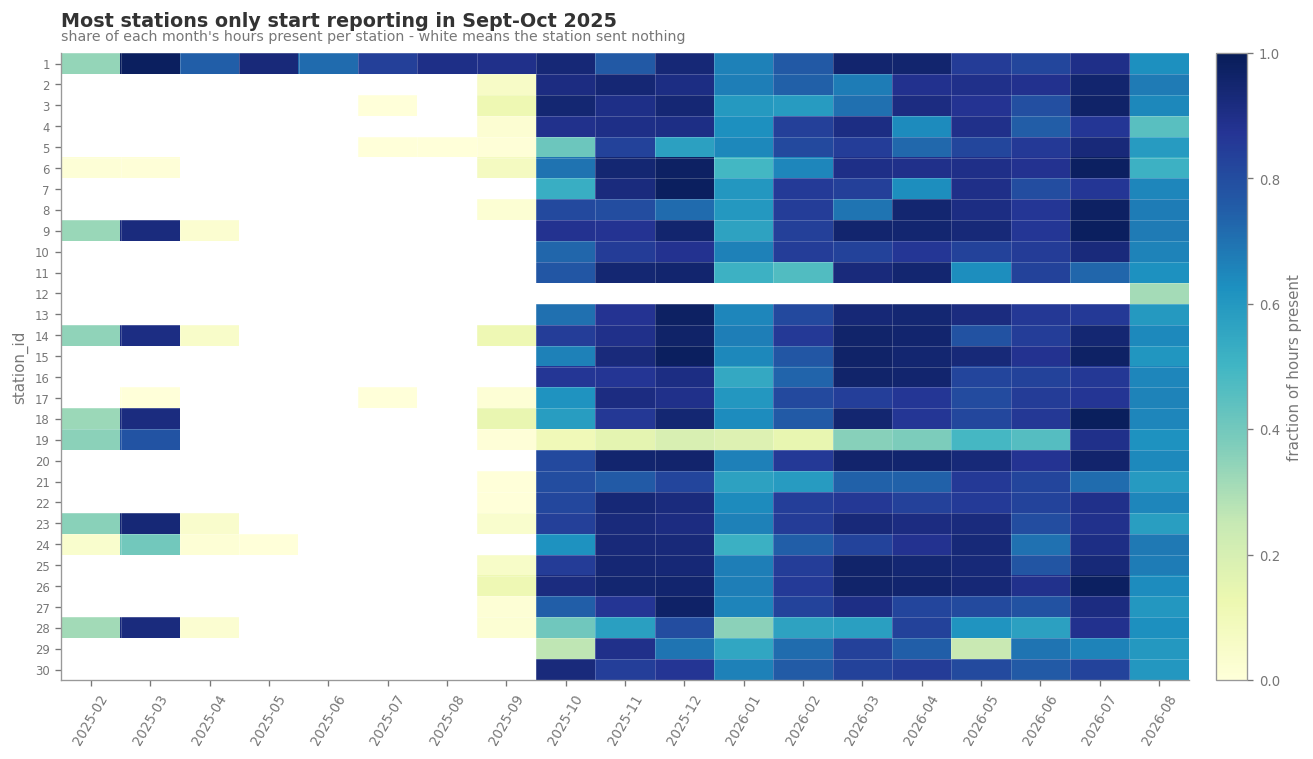

In [4]:
# Coverage heatmap - the clearest single picture of why fold 1 is thin.
grid = (raw.assign(month=raw.ist.dt.to_period("M").astype(str))
           .pivot_table(index="station_id", columns="month",
                        values="value", aggfunc="size")
           .reindex(sorted(raw.station_id.unique())))
hours_in_month = (raw.assign(month=raw.ist.dt.to_period("M"))
                     .groupby("month").size().index.to_timestamp().days_in_month * 24)
frac = grid.div(hours_in_month.values, axis=1).clip(0, 1)

fig, ax = plt.subplots(figsize=(12, 6.4))
im = ax.imshow(frac.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(frac.columns)))
ax.set_xticklabels(frac.columns, rotation=60)
ax.set_yticks(range(len(frac.index)))
ax.set_yticklabels(frac.index, fontsize=7)
ax.set_ylabel("station_id"); ax.grid(False)
# The left edge of the block is the answer: rows start at different months.
ax.set_xticks(np.arange(-.5, len(frac.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(frac.index), 1), minor=True)
ax.grid(which="minor", color="white", lw=.5)
ax.tick_params(which="minor", length=0)
titles(ax, "Most stations only start reporting in Sept-Oct 2025",
       "share of each month's hours present per station - white means the station sent nothing")
fig.colorbar(im, ax=ax, label="fraction of hours present", pad=.02)
plt.tight_layout(); plt.show()

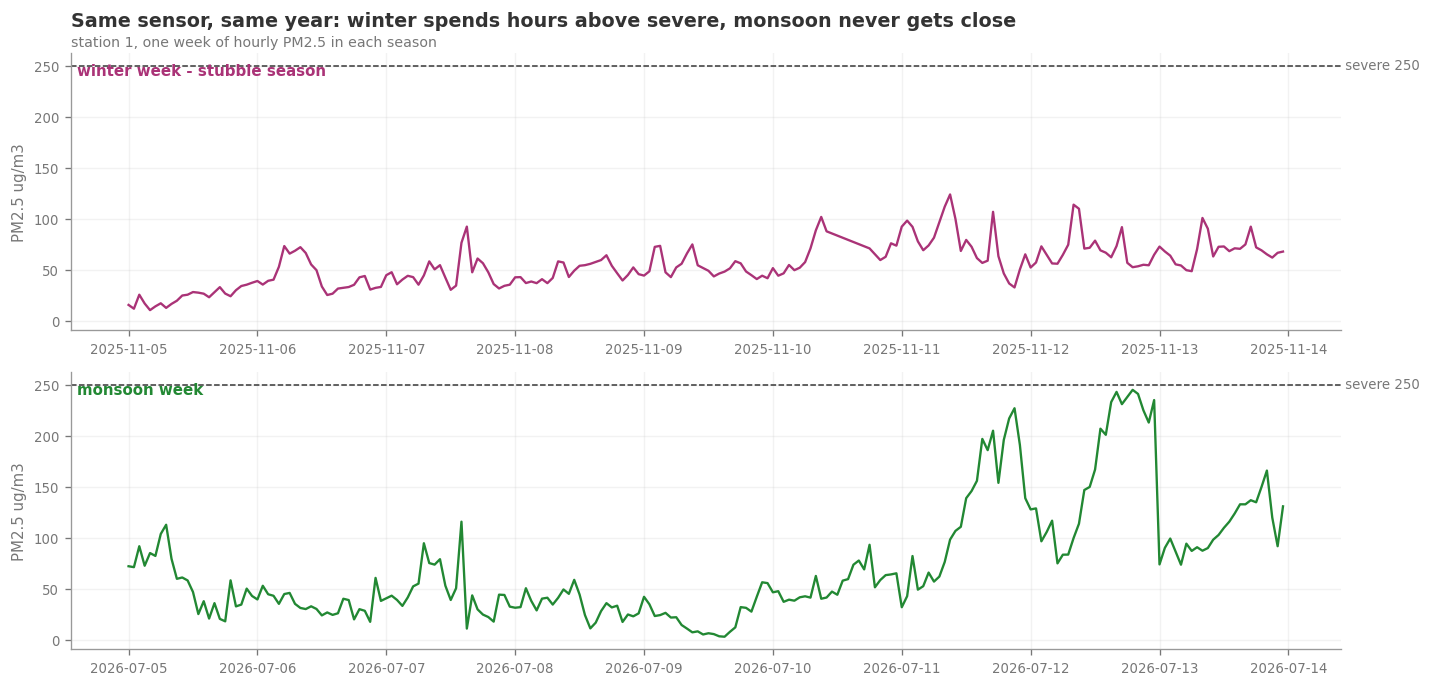

The two weeks above are the same sensor. Winter episodes ramp over hours and sit above
the severe line; the monsoon week barely approaches it. This is why the held-out window
matters so much, and why Phase 3's monsoon-only holdout carried ~50 severe pairs.


In [5]:
# What the data actually looks like: a winter week against a monsoon week, same station.
busiest_pre = raw.groupby("station_id").size().idxmax()
one = raw[raw.station_id == busiest_pre].set_index("ist")["value"]

fig, axes = plt.subplots(2, 1, figsize=(12, 5.8), sharey=True)
for ax, (lo, hi, label, colour) in zip(axes, [
        ("2025-11-05", "2025-11-13", "winter week - stubble season", PAL["purple"]),
        ("2026-07-05", "2026-07-13", "monsoon week", PAL["green"])]):
    seg = one.loc[lo:hi]
    ax.plot(seg.index, seg.values, color=colour, lw=1.4)
    # Shade only the part above the severe line, so an exceedance is visible
    # as area rather than as a line crossing.
    ax.fill_between(seg.index, SEVERE_ABOVE, seg.values,
                    where=seg.values > SEVERE_ABOVE, color=colour, alpha=.25)
    bandline(ax)
    ax.set_ylabel("PM2.5 ug/m3")
    ax.text(.005, .92, label, transform=ax.transAxes, fontsize=9,
            color=colour, fontweight="bold")
titles(axes[0], f"Same sensor, same year: winter spends hours above severe, monsoon never gets close",
       f"station {busiest_pre}, one week of hourly PM2.5 in each season")
plt.tight_layout(); plt.show()

note(f'''
    The two weeks above are the same sensor. Winter episodes ramp over hours and sit above
    the severe line; the monsoon week barely approaches it. This is why the held-out window
    matters so much, and why Phase 3's monsoon-only holdout carried ~50 severe pairs.
''')

## 2. The target's distribution

Its shape decides the scaler, the imputer, and whether a target transform is worth trying.

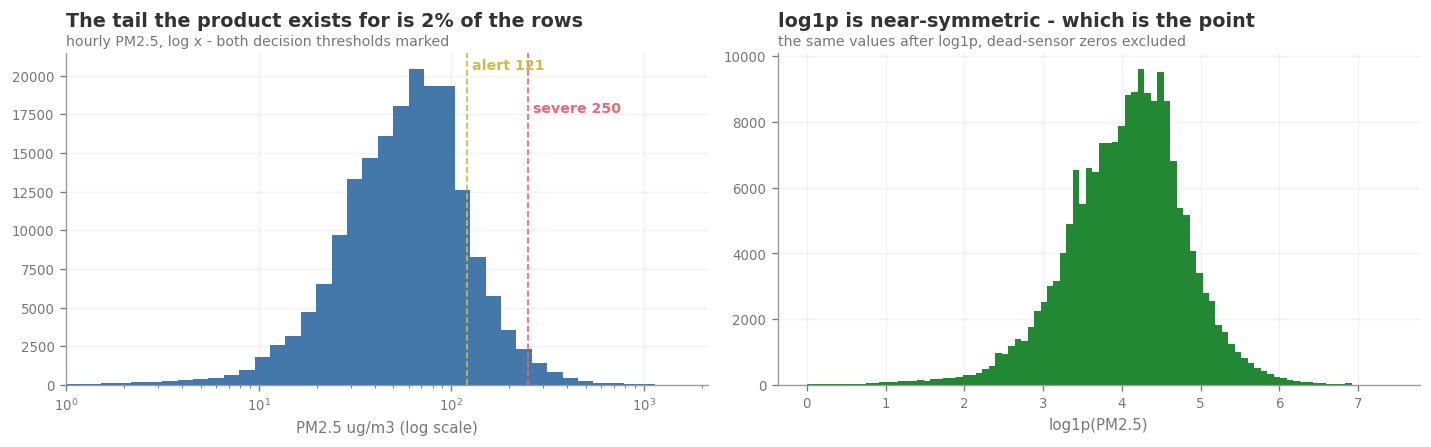

,band,upper,rows,share
0,Good,30.0,40326,20.78%
1,Satisfactory,60.0,58981,30.39%
2,Moderate,90.0,44189,22.77%
3,Poor,120.0,24664,12.71%
4,Very Poor,250.0,22041,11.36%
5,Severe,inf,3858,1.99%


## The target

| statistic | value |
|---|---|
| min / median / mean / max | 0.0 / 58.9 / 72.7 / 1650.0 |
| skew | 4.08 |
| above 250 (severe band) | 3,858 rows, 1.99% |
| above 121 (the alert event) | 25,381 rows, 13.08% |

**Two thresholds, and they are not interchangeable.** This notebook was written against
250 (CPCB's Severe band), which is the regression stage's severe-band metric.
The alert model is graded at **121** (Very Poor), a **7x**
larger event, because 121 is closer to the level at which a person changes plans. Do not
read a 2% base rate in a classification table.

Mean well above median and a maximum ~28x the median: strongly
**right-skewed**. Three consequences carried into `features.py` and `benchmark.py`:

- `RobustScaler` (median, IQR) is the likely right scaler over `StandardScaler`, whose
  mean and standard deviation are both dragged by the tail. Measured, not assumed.
- Median imputation over mean, same reason.
- The skew is what puts a **Tweedie** objective in 

In [6]:
v = raw["value"]
POS = v[v > 0]

# A linear histogram of a skew-4 variable is one bar and a flat line. Log x is
# what makes the shape readable; the log1p panel is what justifies the scaler
# and imputer choices below.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(POS, bins=np.logspace(np.log10(POS.min()), np.log10(POS.max()), 70),
             color=PAL["blue"])
axes[0].set_xscale("log"); axes[0].set_xlabel("PM2.5 ug/m3 (log scale)")
axes[0].set_xlim(1, POS.max() * 1.3)
top = axes[0].get_ylim()[1]
# Staggered heights: at 121 and 250 the two labels would print on top of each other.
for cut, lab, col, h in [(121, "alert 121", PAL["yellow"], .95),
                         (SEVERE_ABOVE, f"severe {SEVERE_ABOVE:.0f}", PAL["red"], .82)]:
    axes[0].axvline(cut, ls="--", lw=1, color=col)
    axes[0].text(cut * 1.06, top * h, lab, fontsize=8.5, color=col, fontweight="bold")
titles(axes[0], "The tail the product exists for is 2% of the rows",
       "hourly PM2.5, log x - both decision thresholds marked")

# POS, not v: the 4,379 exact zeros are dead sensors (section 7a) and would
# print as a spike at 0 that has nothing to do with the shape of real air.
axes[1].hist(np.log1p(POS), bins=90, color=PAL["green"])
axes[1].set_xlabel("log1p(PM2.5)")
titles(axes[1], "log1p is near-symmetric - which is the point",
       "the same values after log1p, dead-sensor zeros excluded")
plt.tight_layout(); plt.show()

# The band table must cover every row, so the open-ended Severe band above the
# last breakpoint is added explicitly - it is 2% of rows and the whole product.
# Lower edge is -1, not 0, so the exact-zero rows land in the first band and
# the assert below can prove the table covers every row. Those zeros are dead
# sensors (section 7a), which is why the band table is not a health statement.
edges = [-1.0] + [b[0] for b in aqi.PM25_BANDS]
names = [b[1] for b in aqi.PM25_BANDS] + [aqi.PM25_BAND_ABOVE]
uppers = [b[0] for b in aqi.PM25_BANDS] + [float("inf")]
bands = pd.DataFrame([
    {"band": n, "upper": u, "rows": int(((v > lo) & (v <= u)).sum()),
     "share": f"{((v > lo) & (v <= u)).mean():.2%}"}
    for lo, u, n in zip(edges, uppers, names)])
assert bands.rows.sum() == len(v), "bands must cover every row"
display(bands)

note(f'''
    ## The target

    | statistic | value |
    |---|---|
    | min / median / mean / max | {v.min():.1f} / {v.median():.1f} / {v.mean():.1f} / {v.max():.1f} |
    | skew | {v.skew():.2f} |
    | above {SEVERE_ABOVE:.0f} (severe band) | {(v > SEVERE_ABOVE).sum():,} rows, {(v > SEVERE_ABOVE).mean():.2%} |
    | above 121 (the alert event) | {(v > 121).sum():,} rows, {(v > 121).mean():.2%} |

    **Two thresholds, and they are not interchangeable.** This notebook was written against
    {SEVERE_ABOVE:.0f} (CPCB's Severe band), which is the regression stage's severe-band metric.
    The alert model is graded at **121** (Very Poor), a **{(v > 121).mean()/(v > SEVERE_ABOVE).mean():.0f}x**
    larger event, because 121 is closer to the level at which a person changes plans. Do not
    read a 2% base rate in a classification table.

    Mean well above median and a maximum ~{v.max()/v.median():.0f}x the median: strongly
    **right-skewed**. Three consequences carried into `features.py` and `benchmark.py`:

    - `RobustScaler` (median, IQR) is the likely right scaler over `StandardScaler`, whose
      mean and standard deviation are both dragged by the tail. Measured, not assumed.
    - Median imputation over mean, same reason.
    - The skew is what puts a **Tweedie** objective in the benchmark. A `log1p` target would
      also symmetrise it (right-hand plot) but compresses exactly the spikes the product
      exists for, and back-transforming is biased in the tail.
''')

## 3. The daily and seasonal cycles

This is what the sin/cos calendar features are meant to capture. If the profiles were flat,
those columns would be dead weight.

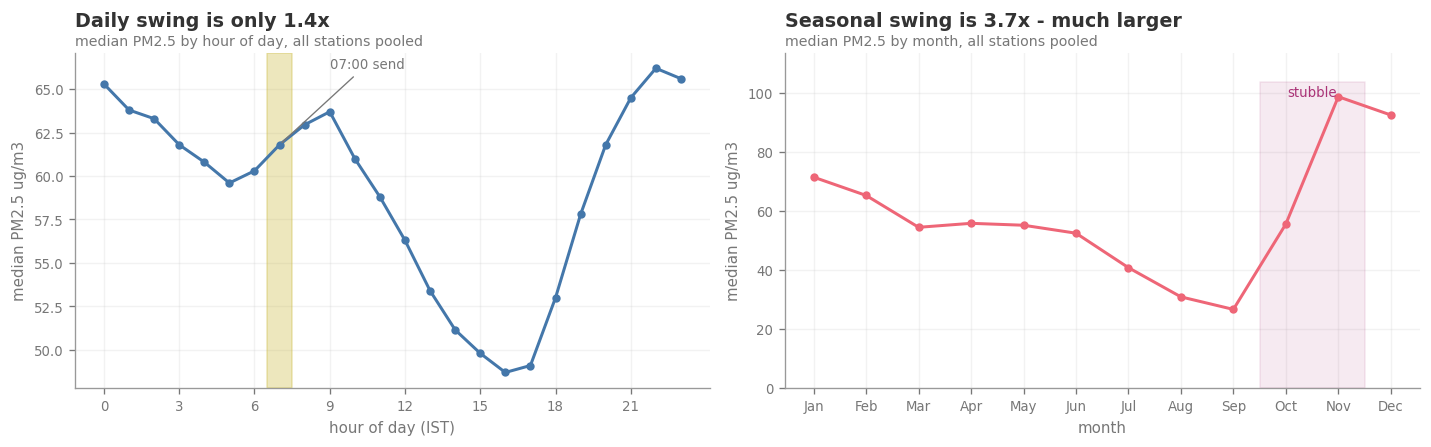

## Cycles

- Daily swing: median **49** at 16:00 IST to
  **66** at 22:00 IST — a
  **1.4x** range. Hour-of-day is real signal.
- Seasonal swing: median **27** (month 9) to
  **99** (month 11) —
  **3.7x**. Larger than the daily swing, and the reason a
  summer-trained model fails in November.
- **Season beats hour by roughly 2.7x**, so
  `month_sin`/`month_cos` carry more than `hour_sin`/`hour_cos` — but the alert is issued
  at a fixed hour, so the daily shape is what a 12h horizon has to cross.


In [7]:
by_hour = raw.groupby(raw.ist.dt.hour)["value"].median()
by_month = raw.groupby(raw.ist.dt.month)["value"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(by_hour.index, by_hour.values, marker="o", ms=4, lw=1.8, color=PAL["blue"])
axes[0].set_xlabel("hour of day (IST)"); axes[0].set_ylabel("median PM2.5 ug/m3")
axes[0].set_xticks(range(0, 24, 3))
axes[0].axvspan(6.5, 7.5, color=PAL["yellow"], alpha=.35)   # the 07:00 IST send
axes[0].annotate("07:00 send", (7, by_hour.loc[7]), xytext=(9, by_hour.max()),
                 fontsize=8, color=PAL["muted"],
                 arrowprops=dict(arrowstyle="-", color=PAL["muted"], lw=.8))
titles(axes[0], f"Daily swing is only {by_hour.max()/by_hour.min():.1f}x",
       "median PM2.5 by hour of day, all stations pooled")

axes[1].plot(by_month.index, by_month.values, marker="o", ms=4, lw=1.8, color=PAL["red"])
axes[1].set_xticks(list(by_month.index))
axes[1].set_xticklabels([MONTHS[m] for m in by_month.index])
axes[1].set_xlabel("month"); axes[1].set_ylabel("median PM2.5 ug/m3")
axes[1].fill_between([9.5, 11.5], 0, by_month.max() * 1.05, color=PAL["purple"], alpha=.1)
axes[1].text(10.5, by_month.max(), "stubble", ha="center", fontsize=8, color=PAL["purple"])
axes[1].set_ylim(0, by_month.max() * 1.15)
titles(axes[1], f"Seasonal swing is {by_month.max()/by_month.min():.1f}x - much larger",
       "median PM2.5 by month, all stations pooled")
plt.tight_layout(); plt.show()

note(f'''
    ## Cycles

    - Daily swing: median **{by_hour.min():.0f}** at {by_hour.idxmin():02d}:00 IST to
      **{by_hour.max():.0f}** at {by_hour.idxmax():02d}:00 IST — a
      **{by_hour.max()/by_hour.min():.1f}x** range. Hour-of-day is real signal.
    - Seasonal swing: median **{by_month.min():.0f}** (month {by_month.idxmin()}) to
      **{by_month.max():.0f}** (month {by_month.idxmax()}) —
      **{by_month.max()/by_month.min():.1f}x**. Larger than the daily swing, and the reason a
      summer-trained model fails in November.
    - **Season beats hour by roughly {(by_month.max()/by_month.min())/(by_hour.max()/by_hour.min()):.1f}x**, so
      `month_sin`/`month_cos` carry more than `hour_sin`/`hour_cos` — but the alert is issued
      at a fixed hour, so the daily shape is what a 12h horizon has to cross.
''')

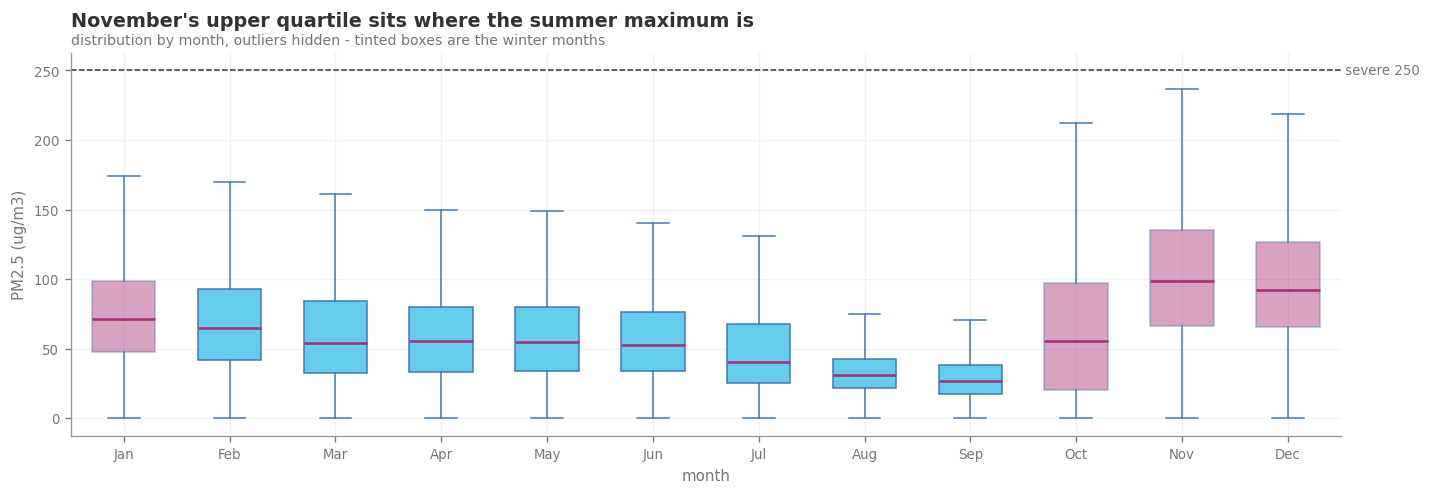

In [8]:
# Spread, not just the median. A boxplot shows the tail that drives the severe metric.
order = sorted(raw.ist.dt.month.unique())
fig, ax = plt.subplots(figsize=(12, 4.2))
bp = ax.boxplot([raw.loc[raw.ist.dt.month == m, "value"] for m in order],
                tick_labels=[MONTHS[m] for m in order], showfliers=False,
                patch_artist=True, widths=.6,
                boxprops=dict(facecolor=PAL["cyan"], edgecolor=PAL["blue"], lw=.9),
                medianprops=dict(color=PAL["purple"], lw=1.6),
                whiskerprops=dict(color=PAL["blue"], lw=.9),
                capprops=dict(color=PAL["blue"], lw=.9))
# Winter months carry the events, so tint them rather than leaving the reader
# to match month numbers against the season.
for m, box in zip(order, bp["boxes"]):
    if m in (10, 11, 12, 1):
        box.set_facecolor(PAL["purple"]); box.set_alpha(.45)
bandline(ax)
ax.set_xlabel("month"); ax.set_ylabel("PM2.5 (ug/m3)")
titles(ax, "November's upper quartile sits where the summer maximum is",
       "distribution by month, outliers hidden - tinted boxes are the winter months")
plt.tight_layout(); plt.show()

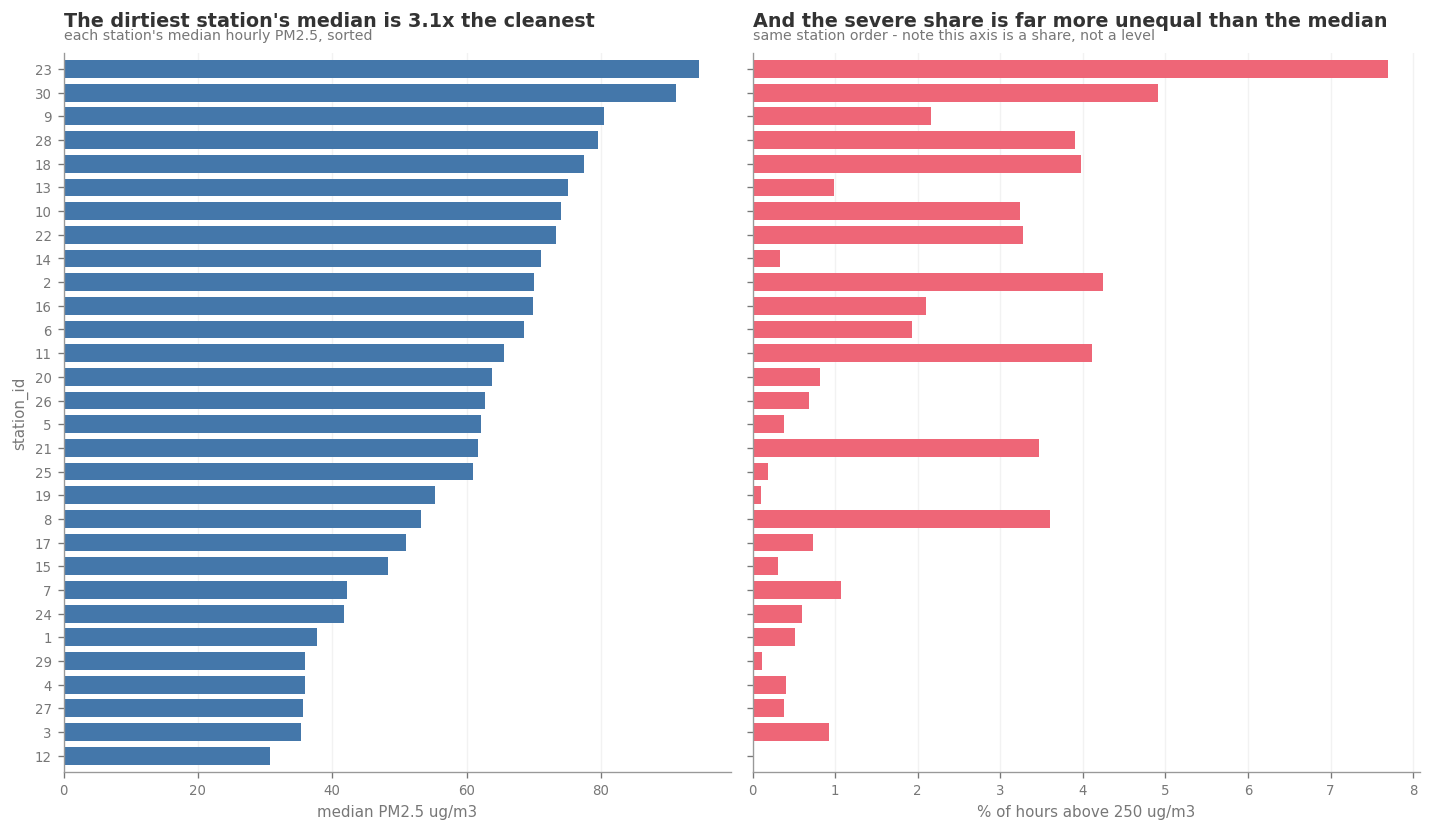

### Stations are not interchangeable

Median PM2.5 ranges **31 to 95 ug/m3**
(**3.1x**) across the 30 stations, and the share of hours in
the severe band ranges **0.00% to 7.69%**.

That spread is what `station_id` as a categorical feature is for. A pooled model without
it would have to infer a station's baseline from its lags alone, and every subscriber
reads exactly one station — so per-station error, not just the average, is reported in the
benchmark.


In [9]:
# Per-station levels. If stations differ systematically, station_id earns its place as a
# feature; if they were identical, a pooled model would need no identity column at all.
med = raw.groupby("station_id")["value"].median().sort_values()
sev = raw.groupby("station_id")["value"].apply(lambda s: (s > SEVERE_ABOVE).mean())

# Horizontal bars: 30 station ids on an x-axis are unreadable at 7pt, and the
# sorted order is the finding.
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
y = np.arange(len(med))
axes[0].barh(y, med.values, color=PAL["blue"], height=.75)
axes[0].set_yticks(y); axes[0].set_yticklabels(med.index, fontsize=8)
axes[0].set_ylabel("station_id"); axes[0].set_xlabel("median PM2.5 ug/m3")
titles(axes[0], f"The dirtiest station's median is {med.max()/med.min():.1f}x the cleanest",
       "each station's median hourly PM2.5, sorted")

axes[1].barh(y, sev.loc[med.index].values * 100, color=PAL["red"], height=.75)
axes[1].set_xlabel(f"% of hours above {SEVERE_ABOVE:.0f} ug/m3")
titles(axes[1], "And the severe share is far more unequal than the median",
       "same station order - note this axis is a share, not a level")
for ax in axes:
    ax.margins(y=.01); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

note(f'''
    ### Stations are not interchangeable

    Median PM2.5 ranges **{med.min():.0f} to {med.max():.0f} ug/m3**
    (**{med.max()/med.min():.1f}x**) across the {len(med)} stations, and the share of hours in
    the severe band ranges **{sev.min():.2%} to {sev.max():.2%}**.

    That spread is what `station_id` as a categorical feature is for. A pooled model without
    it would have to infer a station's baseline from its lags alone, and every subscriber
    reads exactly one station — so per-station error, not just the average, is reported in the
    benchmark.
''')

## 4. Gaps

The gap *length distribution* is the decision, not the gap count. Scattered single hours would
justify a short forward-fill; long blocks do not.

,gap runs,hours lost
1h,3458,3458
2-3h,1475,3415
4-6h,690,3366
7-12h,427,3790
13-24h,504,8654
>24h,316,50570


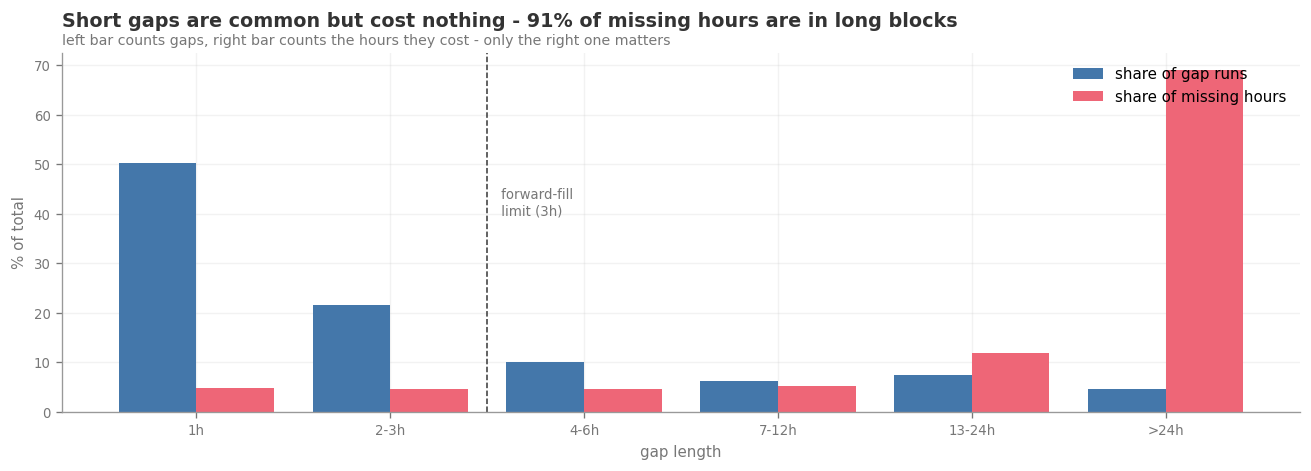

## Gaps

Measured **within each station's own reporting span** — the NaN before a station's first
ever reading is the network being built, not an outage, and counting it would inflate
every number here (132,767 such hours excluded).

- 6,870 gap runs, 73,253 missing station-hours,
  median run **1h**, 90th percentile **15h**,
  longest **4,802h**.
- **91% of all missing hours sit in runs longer than 3 hours** — beyond the
  forward-fill limit build plan §10 sets. Filling them would be fabrication, so
  `features.py` fills nothing and the boosting libraries take NaN natively.
- The other half of the same picture: **72% of gap *runs* are 3h or
  shorter**, and they are what a forward-fill would actually catch — worth
  9% of the missing hours. A fill rule aimed at the
  common case buys almost none of the lost data.


In [10]:
# A station that had not been installed yet is not a "gap". Counting the run of
# NaN before its first reading as missing data would make the network build-out
# look like an outage - so each station is trimmed to its own first..last
# reading before runs are measured.
runs, trimmed = [], 0
for s in wide.columns:
    col = wide[s]
    lo, hi = col.first_valid_index(), col.last_valid_index()
    if lo is None:
        continue
    trimmed += col.isna().sum() - col.loc[lo:hi].isna().sum()
    isna = col.loc[lo:hi].isna().values
    n = 0
    for flag in isna:
        if flag:
            n += 1
        elif n:
            runs.append(n); n = 0
    if n:
        runs.append(n)
runs = pd.Series(runs)

buckets = pd.cut(runs, [0, 1, 3, 6, 12, 24, 10**6],
                 labels=["1h", "2-3h", "4-6h", "7-12h", "13-24h", ">24h"])
tab = buckets.value_counts().sort_index().to_frame("gap runs")
tab["hours lost"] = runs.groupby(buckets, observed=False).sum()
display(tab)

# Two things the reader wants: how OFTEN each gap length happens, and how much
# data each length costs. They rank differently, which is the whole decision.
fig, ax = plt.subplots(figsize=(11, 4))
xpos = np.arange(len(tab))
ax.bar(xpos - .2, tab["gap runs"] / tab["gap runs"].sum() * 100, width=.4,
       color=PAL["blue"], label="share of gap runs")
ax.bar(xpos + .2, tab["hours lost"] / tab["hours lost"].sum() * 100, width=.4,
       color=PAL["red"], label="share of missing hours")
ax.set_xticks(xpos); ax.set_xticklabels(tab.index)
ax.set_xlabel("gap length"); ax.set_ylabel("% of total")
ax.axvline(1.5, ls="--", lw=.9, color=PAL["ink"])
ax.text(1.55, ax.get_ylim()[1] * .55, " forward-fill\n limit (3h)", fontsize=8, color=PAL["muted"])
ax.legend(loc="upper right")
over3 = runs[runs > 3].sum() / runs.sum()
titles(ax, f"Short gaps are common but cost nothing - {over3:.0%} of missing hours are in long blocks",
       "left bar counts gaps, right bar counts the hours they cost - only the right one matters")
plt.tight_layout(); plt.show()

note(f'''
    ## Gaps

    Measured **within each station's own reporting span** — the NaN before a station's first
    ever reading is the network being built, not an outage, and counting it would inflate
    every number here ({trimmed:,} such hours excluded).

    - {len(runs):,} gap runs, {runs.sum():,} missing station-hours,
      median run **{runs.median():.0f}h**, 90th percentile **{runs.quantile(.9):.0f}h**,
      longest **{runs.max():,}h**.
    - **{over3:.0%} of all missing hours sit in runs longer than 3 hours** — beyond the
      forward-fill limit build plan §10 sets. Filling them would be fabrication, so
      `features.py` fills nothing and the boosting libraries take NaN natively.
    - The other half of the same picture: **{(runs <= 3).mean():.0%} of gap *runs* are 3h or
      shorter**, and they are what a forward-fill would actually catch — worth
      {runs[runs <= 3].sum()/runs.sum():.0%} of the missing hours. A fill rule aimed at the
      common case buys almost none of the lost data.
''')

## 5. Autocorrelation — *this decides the lag set*

The **PACF** is the one to read. Plain autocorrelation at lag 3 is inflated by lag 1 acting
through lags 2 and 3; the partial version strips that out and shows which lags carry
information *of their own*. A lag that adds nothing is a column the model has to learn to
ignore.

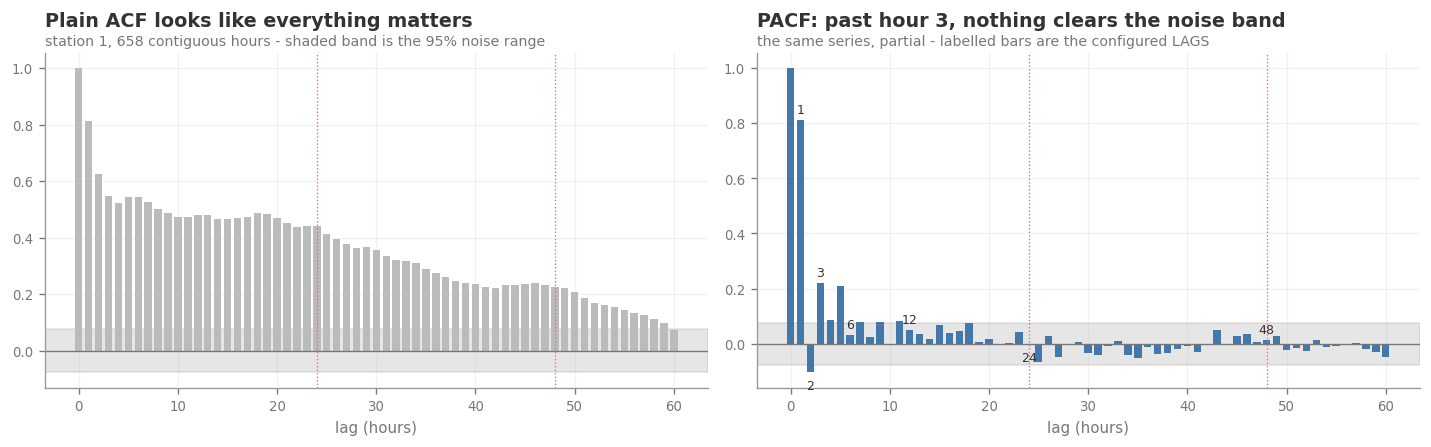

,lag,pacf,significant
0,0,1.000,True
1,1,0.813,True
2,2,-0.105,True
3,3,0.218,True
4,6,0.032,False
5,12,0.049,False
6,24,-0.003,False
7,48,0.012,False


## Autocorrelation (station 1, the one with most history)

    Computed on its **longest unbroken block, 658 hours** — dropping NaN instead
    would join the two sides of a gap and score pairs that are days apart as neighbours.

    - 95% significance band is +/-0.076.
    - Lags with significant partial autocorrelation up to 60h:
      **[1, 2, 3, 4, 5, 7, 9, 11]** (8 of 60).
    - The configured set `features.LAGS = (0, 1, 2, 3, 6, 12, 24, 48)` scores:

| lag | pacf | significant |
|---|---|---|
| 0 | 1.0 | True |
| 1 | 0.813 | True |
| 2 | -0.105 | True |
| 3 | 0.218 | True |
| 6 | 0.032 | False |
| 12 | 0.049 | False |
| 24 | -0.003 | False |
| 48 | 0.012 | False |

    **Read the size, not the star.** The longest unbroken block anywhere in this dataset is
    658 hours, so the significance band is +/-0.076 — wide. An earlier version
    of this cell interpolated and dropped NaN, which glued gap edges together, claimed
    ~11,000 hours and a band of +/-0.018, and so marked lag 24

In [11]:
from statsmodels.tsa.stattools import acf, pacf

busiest = per["rows"].idxmax()
# ACF/PACF assume evenly spaced observations. Dropping NaN would glue the two
# sides of a gap together and quietly compare hours that are days apart, so the
# LONGEST CONTIGUOUS BLOCK is used instead - ANALYSIS ONLY; features.py never fills.
col = wide[busiest]
grp = (col.notna() != col.notna().shift()).cumsum()
blocks = {g: idx for g, idx in col.groupby(grp).groups.items() if col[idx].notna().all()}
series = col[blocks[max(blocks, key=lambda g: len(blocks[g]))]]

LAGS_SHOWN = 60
a = acf(series, nlags=LAGS_SHOWN, fft=True)
p = pacf(series, nlags=LAGS_SHOWN, method="ywm")
ci = 1.96 / math.sqrt(len(series))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, vals, name, colour in [(axes[0], a, "ACF", PAL["grey"]),
                               (axes[1], p, "PACF", PAL["blue"])]:
    # A shaded band reads as "inside here is noise" far faster than two red lines.
    ax.axhspan(-ci, ci, color=PAL["muted"], alpha=.18, zorder=0)
    ax.bar(range(len(vals)), vals, width=.75, color=colour)
    ax.axhline(0, lw=.8, color=PAL["muted"])
    ax.set_xlabel("lag (hours)")
    for l in (24, 48):
        ax.axvline(l, ls=":", lw=.8, color=PAL["red"])
# Only the configured lags get a label - a number on all 60 bars is noise.
for l in features.LAGS:
    if 0 < l <= LAGS_SHOWN:
        axes[1].annotate(f"{l}", (l, p[l]), textcoords="offset points",
                         xytext=(0, 4 if p[l] >= 0 else -10), ha="center",
                         fontsize=7.5, color=PAL["ink"])
titles(axes[0], "Plain ACF looks like everything matters",
       f"station {busiest}, {len(series):,} contiguous hours - shaded band is the 95% noise range")
titles(axes[1], "PACF: past hour 3, nothing clears the noise band",
       "the same series, partial - labelled bars are the configured LAGS")
plt.tight_layout(); plt.show()

sig = [i for i in range(1, LAGS_SHOWN + 1) if abs(p[i]) > ci]
rows = pd.DataFrame({"lag": features.LAGS,
                     "pacf": [round(float(p[l]), 3) if l else 1.0 for l in features.LAGS],
                     "significant": [l == 0 or abs(p[l]) > ci for l in features.LAGS]})
display(rows)

note(f'''
    ## Autocorrelation (station {busiest}, the one with most history)

    Computed on its **longest unbroken block, {len(series):,} hours** — dropping NaN instead
    would join the two sides of a gap and score pairs that are days apart as neighbours.

    - 95% significance band is +/-{ci:.3f}.
    - Lags with significant partial autocorrelation up to {LAGS_SHOWN}h:
      **{sig[:15]}{"..." if len(sig) > 15 else ""}** ({len(sig)} of {LAGS_SHOWN}).
    - The configured set `features.LAGS = {features.LAGS}` scores:

{mdtable(rows)}

    **Read the size, not the star.** The longest unbroken block anywhere in this dataset is
    {len(series):,} hours, so the significance band is +/-{ci:.3f} — wide. An earlier version
    of this cell interpolated and dropped NaN, which glued gap edges together, claimed
    ~11,000 hours and a band of +/-0.018, and so marked lag 24 "significant" at a partial
    autocorrelation of 0.024. That was sample size talking, not signal.

    What survives either way: **lags 1-3 carry almost all of the own-information**
    (|pacf| {abs(p[1]):.2f}, {abs(p[2]):.2f}, {abs(p[3]):.2f}), and every configured lag
    beyond 3 sits under {max(abs(p[l]) for l in features.LAGS if l > 3):.2f}. Those long lags
    are kept anyway because a tree can use a weak column, and because `--tail` adds lag_72
    and lag_168 on the same reasoning. **The ablation, not this band, is where they earn or
    lose their place.**
''')

## 6. Do neighbouring stations correlate? — *this decides the spatial features*

If correlation does not fall with distance, then a "nearest neighbour" column is just another
station's noise and the spatial features should be dropped rather than defended.

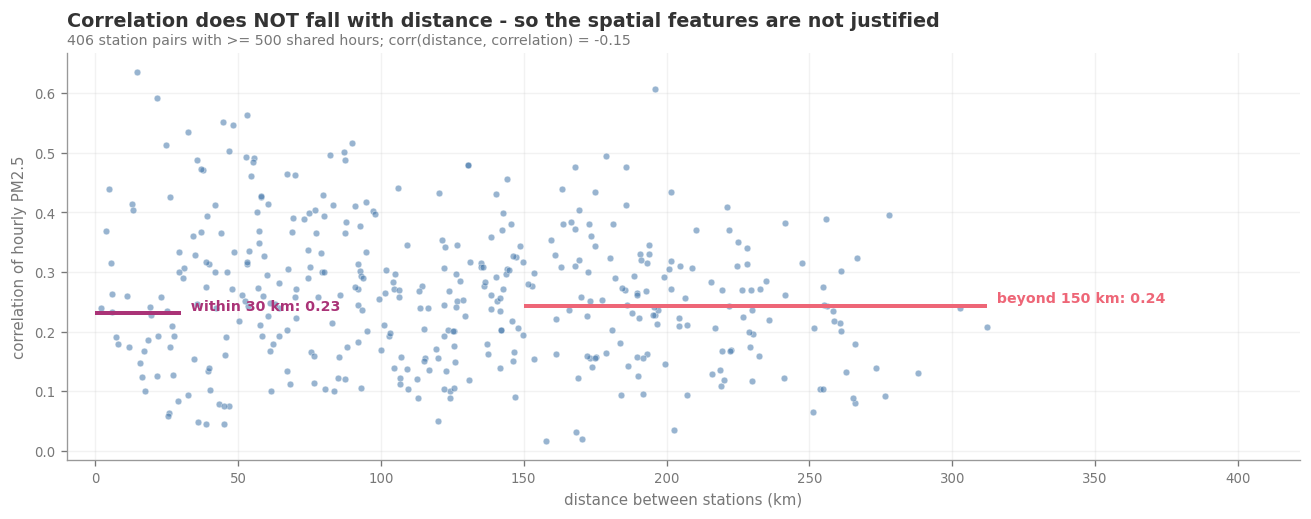

## Spatial structure

406 station pairs with >= 500 shared hours.

| | pairs | median correlation |
|---|---|---|
| within 30 km | 36 | **0.23** |
| beyond 150 km | 144 | **0.24** |

Correlation of distance against correlation: **-0.15**.

**This was predicted to help and did not.** Neighbouring stations agree no more than
stations at opposite ends of Haryana, so a "nearest neighbour" column carries another
station's noise rather than shared airshed signal. The likely reason is that these 30
stations span ~300 km and several airsheds, not one city — and PM2.5 here is driven
locally (traffic, construction, the sensor itself).

**Decision: the neighbour and regional columns are NOT justified** — kept behind
`--spatial`, off by default, because regional transport is a winter phenomenon and most
folds are not winter. Confirmed independently by the ablation: LightGBM scored
**27.443 without** them against **27.841 with**.


In [12]:
def _hav(p1, p2):
    lat1, lon1, lat2, lon2 = map(math.radians, (*p1, *p2))
    h = (math.sin((lat2-lat1)/2)**2
         + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2)
    return 2 * 6371.0 * math.asin(math.sqrt(h))

coords = features.load_coords()
rows = []
for i, a_ in enumerate(wide.columns):
    for b_ in list(wide.columns)[i+1:]:
        both = wide[[a_, b_]].dropna()
        if len(both) < 500 or a_ not in coords or b_ not in coords:
            continue
        rows.append({"a": a_, "b": b_, "n": len(both),
                     "corr": float(both[a_].corr(both[b_])),
                     "km": _hav(coords[a_], coords[b_])})
pairs = pd.DataFrame(rows)
near = pairs[pairs.km <= 30]["corr"]
far = pairs[pairs.km > 150]["corr"]
slope = pairs.km.corr(pairs["corr"])

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.scatter(pairs["km"], pairs["corr"], s=16, alpha=.55, color=PAL["blue"],
           edgecolor="white", linewidth=.4)
# The two group medians ARE the decision, so they are drawn, not left in prose.
for lo, hi, val, lab, col in [(0, 30, near.median(), f"within 30 km: {near.median():.2f}", PAL["purple"]),
                              (150, pairs.km.max(), far.median(), f"beyond 150 km: {far.median():.2f}", PAL["red"])]:
    ax.hlines(val, lo, hi, color=col, lw=2.4)
    ax.text(hi, val, f"  {lab}", va="bottom", fontsize=8.5, color=col, fontweight="bold")
ax.set_xlabel("distance between stations (km)")
ax.set_ylabel("correlation of hourly PM2.5")
ax.set_xlim(-10, pairs.km.max() * 1.35)
titles(ax, "Correlation does NOT fall with distance - so the spatial features are not justified",
       f"{len(pairs)} station pairs with >= 500 shared hours; corr(distance, correlation) = {slope:.2f}")
plt.tight_layout(); plt.show()

note(f'''
    ## Spatial structure

    {len(pairs)} station pairs with >= 500 shared hours.

    | | pairs | median correlation |
    |---|---|---|
    | within 30 km | {len(near)} | **{near.median():.2f}** |
    | beyond 150 km | {len(far)} | **{far.median():.2f}** |

    Correlation of distance against correlation: **{slope:.2f}**.

    **This was predicted to help and did not.** Neighbouring stations agree no more than
    stations at opposite ends of Haryana, so a "nearest neighbour" column carries another
    station's noise rather than shared airshed signal. The likely reason is that these 30
    stations span ~300 km and several airsheds, not one city — and PM2.5 here is driven
    locally (traffic, construction, the sensor itself).

    **Decision: the neighbour and regional columns are NOT justified** — kept behind
    `--spatial`, off by default, because regional transport is a winter phenomenon and most
    folds are not winter. Confirmed independently by the ablation: LightGBM scored
    **27.443 without** them against **27.841 with**.
''')

## 7. Cleaning — three checks nobody runs today

The only cleaning in the pipeline is a range clamp at `backfill_openaq.py:102` rejecting
values outside 0–2000 µg/m³. It cannot see a sensor stuck at 41, and it happily accepts a
reading of exactly 0.

**Finding something here does not mean deleting it.** Each check ends in a decision written
into `features.py` as a named constant with its count, or an explicit decision to leave it.

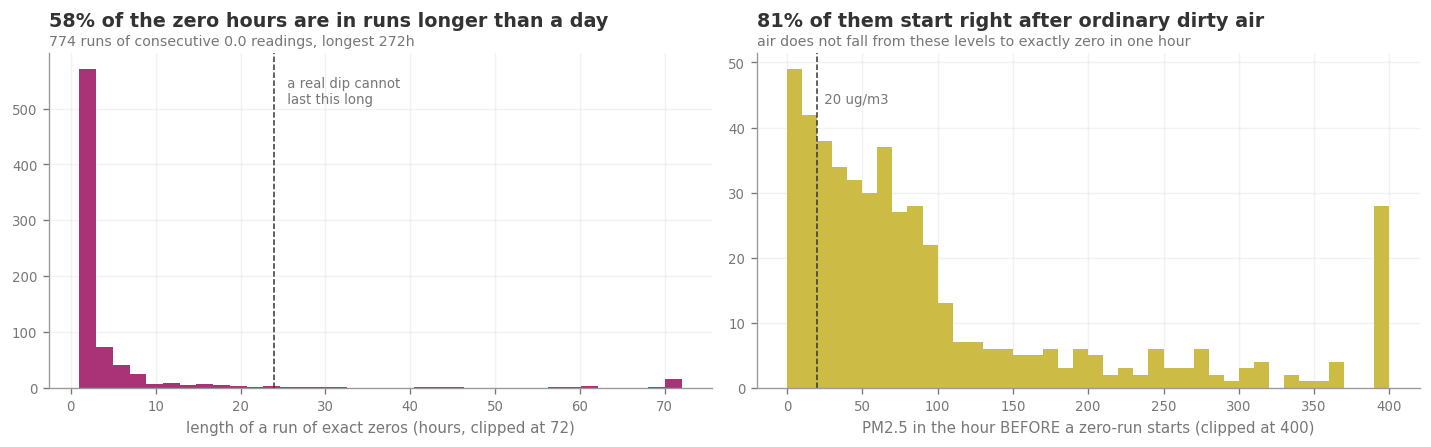

,zero rows
station_id,
2,715
9,390
28,379
11,372
24,362
23,351
29,217
30,212
22,212


### 7a. Exact zeros — a dead sensor, not clean air

**4,379 rows (2.26%)** read exactly 0.0 ug/m3, on
**29 of 30 stations**. Outdoor PM2.5 is
never exactly zero. Two measurements settle what these are:

- **58% of those hours sit in runs longer than 24 hours**
  (29 such runs, longest **272 hours**). A real dip does not
  last eleven days.
- **81% of zero-runs begin in the hour immediately after a reading
  above 20 ug/m3** (median before a run: **64.4**, max
  **1000.0**). Air does not fall from 1000 to 0 in one hour.

**Decision: masked as missing, not deleted, not kept.** `features.DROP_EXACT_ZERO` in
`scripts/features.py` carries this rule and this count. Masking rather than deleting means
a dead sensor produces the same absence as an offline one, which the gap policy already
handles correctly. The range clamp at `backfill_openaq.py:102` cannot catch these, because
0.0 is inside [0, 2000]; the raw table stays raw and the rule lives in one visible place.


In [13]:
zeros = raw[raw.value == 0.0]
by_station = zeros.groupby("station_id").size().sort_values(ascending=False)

# Raw pivot WITHOUT the zero mask, so this section can see what was masked.
_r = raw.copy()
zwide = _r.pivot_table(index="hour", columns="station_id", values="value").reindex(
    pd.RangeIndex(int(_r.hour.min()), int(_r.hour.max()) + 1))

runs_z, befores = [], []
for s in zwide.columns:
    vv = zwide[s]; iz = (vv == 0.0).fillna(False)
    n = 0
    for f in iz.values:
        if f: n += 1
        elif n: runs_z.append(n); n = 0
    if n: runs_z.append(n)
    for h in vv.index[iz & ~iz.shift(1, fill_value=False)]:
        prev = vv.get(h - 1, np.nan)
        if pd.notna(prev): befores.append(prev)
runs_z, befores = pd.Series(runs_z), pd.Series(befores)
long_share = runs_z[runs_z > 24].sum() / max(1, runs_z.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(runs_z.clip(upper=72), bins=36, color=PAL["purple"])
axes[0].axvline(24, ls="--", lw=.9, color=PAL["ink"])
axes[0].text(25, axes[0].get_ylim()[1] * .85, " a real dip cannot\n last this long",
             fontsize=8, color=PAL["muted"])
axes[0].set_xlabel("length of a run of exact zeros (hours, clipped at 72)")
titles(axes[0], f"{long_share:.0%} of the zero hours are in runs longer than a day",
       f"{len(runs_z)} runs of consecutive 0.0 readings, longest {runs_z.max()}h")

axes[1].hist(befores.clip(upper=400), bins=40, color=PAL["yellow"])
axes[1].axvline(20, ls="--", lw=.9, color=PAL["ink"])
axes[1].text(22, axes[1].get_ylim()[1] * .85, " 20 ug/m3", fontsize=8, color=PAL["muted"])
axes[1].set_xlabel("PM2.5 in the hour BEFORE a zero-run starts (clipped at 400)")
titles(axes[1], f"{(befores > 20).mean():.0%} of them start right after ordinary dirty air",
       "air does not fall from these levels to exactly zero in one hour")
plt.tight_layout(); plt.show()

display(by_station.head(10).to_frame("zero rows"))

note(f'''
    ### 7a. Exact zeros — a dead sensor, not clean air

    **{len(zeros):,} rows ({len(zeros)/len(raw):.2%})** read exactly 0.0 ug/m3, on
    **{(by_station > 0).sum()} of {raw.station_id.nunique()} stations**. Outdoor PM2.5 is
    never exactly zero. Two measurements settle what these are:

    - **{long_share:.0%} of those hours sit in runs longer than 24 hours**
      ({(runs_z > 24).sum()} such runs, longest **{runs_z.max()} hours**). A real dip does not
      last eleven days.
    - **{(befores > 20).mean():.0%} of zero-runs begin in the hour immediately after a reading
      above 20 ug/m3** (median before a run: **{befores.median():.1f}**, max
      **{befores.max():.1f}**). Air does not fall from {befores.max():.0f} to 0 in one hour.

    **Decision: masked as missing, not deleted, not kept.** `features.DROP_EXACT_ZERO` in
    `scripts/features.py` carries this rule and this count. Masking rather than deleting means
    a dead sensor produces the same absence as an offline one, which the gap policy already
    handles correctly. The range clamp at `backfill_openaq.py:102` cannot catch these, because
    0.0 is inside [0, 2000]; the raw table stays raw and the rule lives in one visible place.
''')

In [14]:
import itertools
flat = []
for s in wide.columns:
    vals = wide[s]
    run_val, run_len, run_end = None, 0, None
    for h, x in vals.items():
        if pd.notna(x) and x == run_val:
            run_len += 1; run_end = h
        else:
            if run_len >= 6:
                flat.append({"station": s, "value": run_val, "hours": run_len + 1,
                             "ended": pd.Timestamp(run_end*3600, unit="s", tz="UTC")
                                        .tz_convert(IST)})
            run_val, run_len, run_end = x, 0, h
flat = pd.DataFrame(flat)
note(f'''
    ### 7b. Flatlines — a stuck sensor

    Runs of >= 7 identical consecutive hourly readings: **{len(flat)}**.
''')
if len(flat):
    display(flat.sort_values("hours", ascending=False).head(12))
    note(f'''
    - Longest run: **{flat.hours.max()} hours** at station {flat.loc[flat.hours.idxmax(), "station"]},
      value {flat.loc[flat.hours.idxmax(), "value"]:.1f}.
    - Total hours inside a flatline run: **{flat.hours.sum():,}**
      ({flat.hours.sum()/len(raw):.2%} of all readings).
    - Note low values repeat by chance at 1-decimal resolution; a run at a value of 0.0 or a
      run longer than a day is the suspicious kind.
    ''')
else:
    note("    No flatline runs found. The range clamp was not hiding a stuck sensor.")

### 7b. Flatlines — a stuck sensor

Runs of >= 7 identical consecutive hourly readings: **89**.


,station,value,hours,ended
30,16,24.5,86,2025-10-06 07:30:00+05:30
31,16,89.2,48,2026-02-27 10:30:00+05:30
3,3,62.0,48,2026-01-01 13:30:00+05:30
81,29,114.0,40,2026-06-18 12:30:00+05:30
5,3,12.8,30,2026-07-08 09:30:00+05:30
1,2,27.9,29,2025-11-06 13:30:00+05:30
13,6,52.8,28,2026-01-04 06:30:00+05:30
88,30,9.1,24,2026-07-20 09:30:00+05:30
52,17,18.7,23,2026-08-11 22:30:00+05:30
69,23,54.7,23,2025-10-03 09:30:00+05:30


- Longest run: **86 hours** at station 16,
  value 24.5.
- Total hours inside a flatline run: **1,226**
  (0.63% of all readings).
- Note low values repeat by chance at 1-decimal resolution; a run at a value of 0.0 or a
  run longer than a day is the suspicious kind.


In [15]:
spikes = []
for s in wide.columns:
    v_ = wide[s]
    prev, nxt = v_.shift(1), v_.shift(-1)
    neighbour_max = pd.concat([prev, nxt], axis=1).max(axis=1)
    # Isolated = at least 3x both neighbours AND above the severe band. A real
    # pollution event ramps; a sensor glitch does not.
    mask = (v_ > SEVERE_ABOVE) & (v_ > 3 * neighbour_max) & prev.notna() & nxt.notna()
    for h in v_.index[mask.fillna(False)]:
        spikes.append({"station": s, "value": v_[h], "prev": prev[h], "next": nxt[h],
                       "ist": pd.Timestamp(h*3600, unit="s", tz="UTC").tz_convert(IST)})
spikes = pd.DataFrame(spikes)
note(f'''
    ### 7c. Isolated spikes

    Readings above {SEVERE_ABOVE:.0f} ug/m3 that are more than 3x BOTH adjacent hours:
    **{len(spikes)}** of {(raw.value > SEVERE_ABOVE).sum():,} severe readings
    ({len(spikes)/max(1,(raw.value > SEVERE_ABOVE).sum()):.2%}).

    A real NCR winter episode ramps over hours. A value that triples and collapses inside two
    hours is the shape of a glitch. This is a *flag*, not a delete — 1650 ug/m3 is genuinely
    reachable here.
''')
if len(spikes):
    display(spikes.sort_values("value", ascending=False).head(10))

### 7c. Isolated spikes

Readings above 250 ug/m3 that are more than 3x BOTH adjacent hours:
**109** of 3,858 severe readings
(2.83%).

A real NCR winter episode ramps over hours. A value that triples and collapses inside two
hours is the shape of a glitch. This is a *flag*, not a delete — 1650 ug/m3 is genuinely
reachable here.


,station,value,prev,next,ist
57,21,1650.0,4.800,6.67,2026-04-30 11:30:00+05:30
33,9,1240.0,376.000,30.70,2026-05-03 22:30:00+05:30
30,8,950.0,133.000,263.00,2026-02-10 05:30:00+05:30
85,23,944.0,295.000,207.00,2025-11-27 23:30:00+05:30
6,2,933.0,244.000,84.40,2025-11-12 08:30:00+05:30
43,15,924.0,0.005,47.10,2025-11-27 15:30:00+05:30
103,30,852.0,145.000,259.00,2026-06-10 06:30:00+05:30
60,21,850.0,72.900,176.00,2026-05-21 15:30:00+05:30
79,22,845.0,69.400,71.20,2026-05-29 06:30:00+05:30
45,16,843.0,106.000,251.00,2025-12-09 10:30:00+05:30


## 8. What this notebook decided

Three decisions, each carried into code with the measurement that justified it.

In [16]:
note(f'''
    ## Decisions taken from this notebook

    | question | evidence | decision |
    |---|---|---|
    | exact zeros | {len(zeros):,} rows, {long_share:.0%} in runs > 24h, {(befores > 20).mean():.0%} of runs start after a reading > 20 | **masked as missing** — `features.DROP_EXACT_ZERO` |
    | spatial features | corr 0.23 within 30 km vs 0.24 beyond 150 km; corr(distance, correlation) -0.15 | **not justified** — off by default, behind `--spatial` |
    | lag set | PACF on {len(series):,} unbroken hours (station {busiest}): lags 1-3 carry the signal, lags {[l for l in features.LAGS if l and abs(p[l]) <= ci]} sit inside the +/-{ci:.3f} band | **kept, flagged** — a weak column is not a wrong column; the ablation decides |
    | flatlines | {len(flat)} runs of >= 7 identical hours, {flat.hours.sum():,} hours total, largely the zero runs above | **covered by the zero rule**; no separate constant |
    | isolated spikes | {len(spikes)} of {(raw.value > SEVERE_ABOVE).sum():,} severe readings triple both neighbours | **kept** — 1650 ug/m3 is reachable in NCR winter, and deleting the tail would gut the metric the product exists for |

    The standing rule: **a cleaning rule is adopted only as a named constant in
    `scripts/features.py` carrying its count, or it is not applied.** No silent drops.
''')

## Decisions taken from this notebook

| question | evidence | decision |
|---|---|---|
| exact zeros | 4,379 rows, 58% in runs > 24h, 81% of runs start after a reading > 20 | **masked as missing** — `features.DROP_EXACT_ZERO` |
| spatial features | corr 0.23 within 30 km vs 0.24 beyond 150 km; corr(distance, correlation) -0.15 | **not justified** — off by default, behind `--spatial` |
| lag set | PACF on 658 unbroken hours (station 1): lags 1-3 carry the signal, lags [6, 12, 24, 48] sit inside the +/-0.076 band | **kept, flagged** — a weak column is not a wrong column; the ablation decides |
| flatlines | 89 runs of >= 7 identical hours, 1,226 hours total, largely the zero runs above | **covered by the zero rule**; no separate constant |
| isolated spikes | 109 of 3,858 severe readings triple both neighbours | **kept** — 1650 ug/m3 is reachable in NCR winter, and deleting the tail would gut the metric the product exists for |

The standing rule: **a cleaning rule is adopted only as a 

In [17]:
# CACHE is <repo>/data/pm25_history.csv, so its grandparent is the repo root —
# correct whether the notebook is run from notebooks/ or from the root.
out = os.path.join(os.path.dirname(os.path.dirname(CACHE)), "docs", "eda.md")
header = f'''# EDA — Phase 4

Generated by `notebooks/01_eda_cleaning.ipynb` on {pd.Timestamp.now(IST):%Y-%m-%d %H:%M} IST.
Do not hand-edit — re-run the notebook (Run All).

Source: `data/pm25_history.csv` (gitignored), {len(raw):,} rows, OpenAQ hourly PM2.5.
Zero Neon wakes: the notebook reads the local cache only.
'''
os.makedirs(os.path.dirname(out), exist_ok=True)
with open(out, "w", encoding="utf-8") as fh:
    fh.write(header + "\n\n" + "\n\n".join(REPORT) + "\n")
print("wrote", out, f"({len(REPORT)} sections)")

wrote C:\Users\sumee\Documents\AQI project\docs\eda.md (15 sections)
